Block: Conv 3x3 -> MaxPool 2x2
RF-Folge: [4, 10, 22, 46, 94, 190, 382, 766, 1534, 3070]


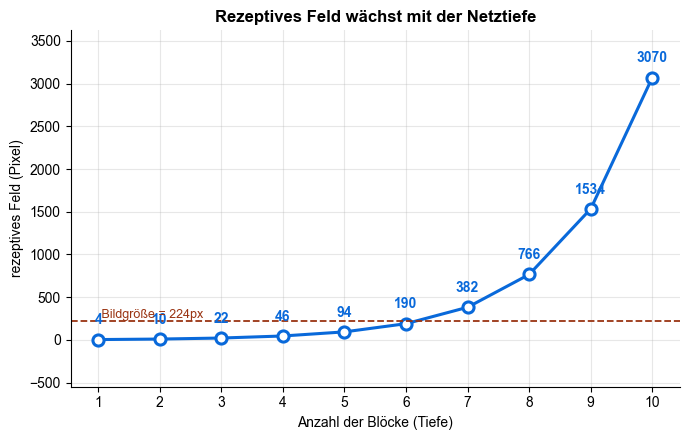

In [5]:
"""
Rezeptives Feld über die Netztiefe
----------------------------------
Berechnet, wie groß das rezeptive Feld (in Eingabepixeln) wird, wenn man
ein festes Block-Muster (z. B. Conv 3x3 -> MaxPool 2x2) x-mal hintereinander
schaltet, und stellt die Folge (z. B. 4, 10, ...) als Linienplot dar.

iludis.de
"""

import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1) Konfiguration  ---  hier anpassen
# ---------------------------------------------------------------------------
# Ein "Block" ist eine Liste von Operationen (Name, Kernel k, Stride s).
# Beispiel: 3x3-Faltung (Stride 1), danach 2x2-MaxPooling (Stride 2).
BLOCK = [
    ("Conv 3x3", 3, 1),
    ("MaxPool 2x2", 2, 2),
]

ANZAHL_BLOECKE = 10      # wie oft das Muster wiederholt wird ('x')
BILDGROESSE   = 224      # Eingabe-Kantenlänge in Pixeln (für die Sättigungslinie)


# ---------------------------------------------------------------------------
# 2) Berechnung
# ---------------------------------------------------------------------------
# Rekursion pro Operation:
#   r_neu = r_alt + (k - 1) * j_alt      (rezeptives Feld)
#   j_neu = j_alt * s                    (kumulierter Sprung)
# Startwerte: r = 1, j = 1.
def rf_folge(block, wiederholungen):
    """Gibt das rezeptive Feld nach JEDER Block-Wiederholung zurück."""
    r, j = 1, 1
    folge = []
    for _ in range(wiederholungen):
        for _name, k, s in block:
            r = r + (k - 1) * j
            j = j * s
        folge.append(r)          # ein Punkt pro vollständigem Block
    return folge


tiefe = list(range(1, ANZAHL_BLOECKE + 1))
rf = rf_folge(BLOCK, ANZAHL_BLOECKE)

print("Block:", " -> ".join(name for name, _, _ in BLOCK))
print("RF-Folge:", rf)


# ---------------------------------------------------------------------------
# 3) Plot
# ---------------------------------------------------------------------------
plt.rcParams["font.family"] = "Arial"
AKZENT = "#0969DA"

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(tiefe, rf, marker="o", markersize=8, linewidth=2.2,
        color=AKZENT, markerfacecolor="white", markeredgewidth=2.2,
        label="rezeptives Feld")

# Werte an den Punkten beschriften
for x, y in zip(tiefe, rf):
    ax.annotate(str(y), (x, y), textcoords="offset points",
                xytext=(0, 11), ha="center", fontsize=10,
                fontweight="bold", color=AKZENT)

# Sättigungslinie: ab hier sieht ein Neuron das ganze Bild
ax.axhline(BILDGROESSE, color="#9a3412", linestyle="--", linewidth=1.3)
ax.text(tiefe[0], BILDGROESSE, f" Bildgröße = {BILDGROESSE}px",
        color="#9a3412", va="bottom", ha="left", fontsize=9)

ax.set_title("Rezeptives Feld wächst mit der Netztiefe", fontweight="bold")
ax.set_xlabel("Anzahl der Blöcke (Tiefe)")
ax.set_ylabel("rezeptives Feld (Pixel)")
ax.set_xticks(tiefe)
ax.grid(True, alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.margins(y=0.18)

fig.tight_layout()
fig.savefig("rf_wachstum.png", dpi=130)
plt.show()

Schichten: 27   RF-wirksam (k>1): 14   flach (k=1): 13
finales rezeptives Feld: 315 x 315 Pixel


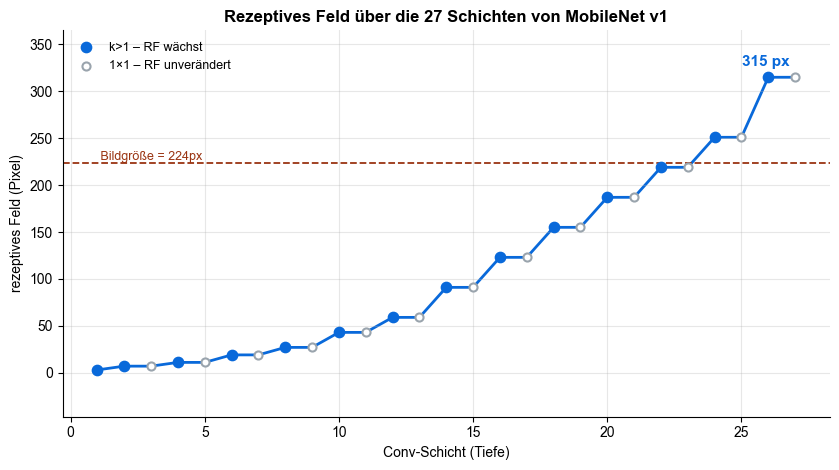

In [4]:
"""
Rezeptives Feld über die Netztiefe
----------------------------------
Berechnet das rezeptive Feld (in Eingabepixeln) Schicht für Schicht und stellt
das Wachstum als Linienplot dar. Unterstützt zwei Eingabearten:

  (1) ein festes Block-Muster, das x-mal wiederholt wird
      (z. B. Conv 3x3 -> MaxPool 2x2)
  (2) eine explizite Schichtfolge mit gemischten Kerneln/Strides
      (z. B. das komplette MobileNet v1)

Ein "Layer" ist ein Tupel (Name, Kernel k, Stride s).
1x1-Faltungen (k=1) tragen nichts zum rezeptiven Feld bei -> die Kurve ist dort flach.

iludis.de
"""

import matplotlib.pyplot as plt


# ---------------------------------------------------------------------------
# 1) Netz-Definitionen
# ---------------------------------------------------------------------------
def wiederhole(block, x):
    """Wiederholt ein Block-Muster (Liste von Layern) x-mal."""
    layers = []
    for _ in range(x):
        layers += block
    return layers


def mobilenet_v1():
    """Komplette Schichtfolge von MobileNet v1 (27 Conv-Layer).
    Block = Depthwise 3x3 + Pointwise 1x1. Fünf Stride-2-Stellen."""
    layers = [("Conv 3x3 /s2", 3, 2)]                       # 224 -> 112
    dw_strides = [1, 2, 1, 2, 1, 2, 1, 1, 1, 1, 1, 2, 1]    # 13 Depthwise-Blöcke
    for i, s in enumerate(dw_strides, 1):
        layers.append((f"dw 3x3{' /s2' if s == 2 else ''}", 3, s))
        layers.append(("pw 1x1", 1, 1))
    return layers


# ---------------------------------------------------------------------------
# 2) Berechnung  ---  pro Layer aufzeichnen
# ---------------------------------------------------------------------------
# Rekursion pro Operation:
#   r_neu = r_alt + (k - 1) * j_alt      (rezeptives Feld)
#   j_neu = j_alt * s                    (kumulierter Sprung)
def rf_pro_layer(layers):
    r, j = 1, 1
    rs, ks = [], []
    for _name, k, s in layers:
        r = r + (k - 1) * j
        j = j * s
        rs.append(r)
        ks.append(k)
    return rs, ks


# ---------------------------------------------------------------------------
# 3) Konfiguration  ---  hier umschalten
# ---------------------------------------------------------------------------
NETZ        = mobilenet_v1()          # oder: wiederhole([("Conv 3x3",3,1),("MaxPool 2x2",2,2)], 5)
BILDGROESSE = 224
TITEL       = "Rezeptives Feld über die 27 Schichten von MobileNet v1"

rs, ks = rf_pro_layer(NETZ)
xs = list(range(1, len(NETZ) + 1))
print(f"Schichten: {len(NETZ)}   RF-wirksam (k>1): {sum(k > 1 for k in ks)}   "
      f"flach (k=1): {sum(k == 1 for k in ks)}")
print(f"finales rezeptives Feld: {rs[-1]} x {rs[-1]} Pixel")


# ---------------------------------------------------------------------------
# 4) Plot
# ---------------------------------------------------------------------------
plt.rcParams["font.family"] = "Arial"
AKZENT, GRAU, WARN = "#0969DA", "#9aa4ad", "#9a3412"

fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.plot(xs, rs, "-", color=AKZENT, linewidth=2, zorder=1)

# wachsende (3x3/5x5) vs. flache (1x1) Schichten getrennt markieren
gx = [x for x, k in zip(xs, ks) if k > 1]
gy = [r for r, k in zip(rs, ks) if k > 1]
fx = [x for x, k in zip(xs, ks) if k == 1]
fy = [r for r, k in zip(rs, ks) if k == 1]
ax.scatter(gx, gy, s=55, color=AKZENT, zorder=3, label="k>1 – RF wächst")
ax.scatter(fx, fy, s=34, facecolor="white", edgecolor=GRAU,
           linewidth=1.5, zorder=3, label="1×1 – RF unverändert")

# Bildgröße als Sättigungslinie
ax.axhline(BILDGROESSE, color=WARN, linestyle="--", linewidth=1.3)
ax.text(xs[0], BILDGROESSE, f" Bildgröße = {BILDGROESSE}px",
        color=WARN, va="bottom", ha="left", fontsize=9)

# Endwert beschriften
ax.annotate(f"{rs[-1]} px", (xs[-1], rs[-1]), textcoords="offset points",
            xytext=(-4, 8), ha="right", fontsize=11, fontweight="bold", color=AKZENT)

ax.set_title(TITEL, fontweight="bold")
ax.set_xlabel("Conv-Schicht (Tiefe)")
ax.set_ylabel("rezeptives Feld (Pixel)")
ax.grid(True, alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.margins(y=0.16)
ax.legend(frameon=False, fontsize=9, loc="upper left")

fig.tight_layout()
fig.savefig("rf_wachstum.png", dpi=130)
plt.show()